In [1]:
import math

import matplotlib.pyplot as plt
import os

import keras
from keras import *
from keras.layers import *
from keras.activations import *
from keras.models import load_model, save_model
import tensorflow as tf
import numpy as np

import matplotlib.pyplot as plt

In [2]:
model_name = 'regression_simple_trained_model.h5'
nsamples = 1000
val_ratio = 0.3
test_ratio = 0.2
x_values = np.random.uniform(low=0, high=(2 * math.pi), size=nsamples)
y_values = np.sin(x_values)

In [3]:
val_split = int(val_ratio * nsamples)
test_split = int(val_split + (test_ratio * nsamples))
x_val, x_test, x_train = np.split(x_values, [val_split, test_split])
y_val, y_test, y_train = np.split(y_values, [val_split, test_split])

In [4]:
print(x_val.shape, x_test.shape, x_train.shape)
print(y_val.shape, y_test.shape, y_train.shape)

(300,) (200,) (500,)
(300,) (200,) (500,)


<function matplotlib.pyplot.show(close=None, block=None)>

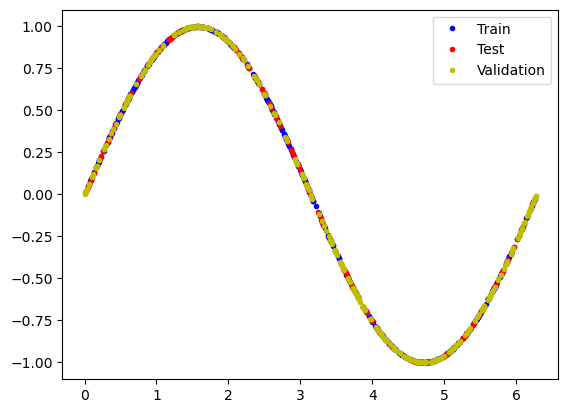

In [5]:
plt.plot(x_train, y_train, 'b.', label="Train")
plt.plot(x_test, y_test, 'r.', label="Test")
plt.plot(x_val, y_val, 'y.', label="Validation")
plt.legend()
plt.show

In [11]:
model = keras.Sequential()
model.add(layers.Dense(18, activation='relu', name='layer1', input_shape=(1,)))
model.add(layers.Dense(18, activation='relu', name='layer2'))
model.add(layers.Dense(10, activation='relu', name='layer3'))
#model.add(layers.Dense(10, activation='relu', name='layer4'))
model.add(layers.Dense(1))

model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
layer1 (Dense)               (None, 18)                36        
_________________________________________________________________
layer2 (Dense)               (None, 18)                342       
_________________________________________________________________
layer3 (Dense)               (None, 10)                190       
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 11        
Total params: 579
Trainable params: 579
Non-trainable params: 0
_________________________________________________________________


Epoch 1/500
5/5 [==============================] - 0s 31ms/step - loss: 1.0059 - mae: 1.0059 - val_loss: 0.9083 - val_mae: 0.9083
Epoch 2/500
5/5 [==============================] - 0s 13ms/step - loss: 0.8081 - mae: 0.8081 - val_loss: 0.7611 - val_mae: 0.7611
Epoch 3/500
5/5 [==============================] - 0s 14ms/step - loss: 0.7194 - mae: 0.7194 - val_loss: 0.6696 - val_mae: 0.6696
Epoch 4/500
5/5 [==============================] - 0s 13ms/step - loss: 0.6620 - mae: 0.6620 - val_loss: 0.6007 - val_mae: 0.6007
Epoch 5/500
5/5 [==============================] - 0s 13ms/step - loss: 0.6181 - mae: 0.6181 - val_loss: 0.5556 - val_mae: 0.5556
Epoch 6/500
5/5 [==============================] - 0s 13ms/step - loss: 0.5811 - mae: 0.5811 - val_loss: 0.5202 - val_mae: 0.5202
Epoch 7/500
5/5 [==============================] - 0s 13ms/step - loss: 0.5550 - mae: 0.5550 - val_loss: 0.5090 - val_mae: 0.5090
Epoch 8/500
5/5 [==============================] - 0s 13ms/step - loss: 0.5410 - mae: 0.54

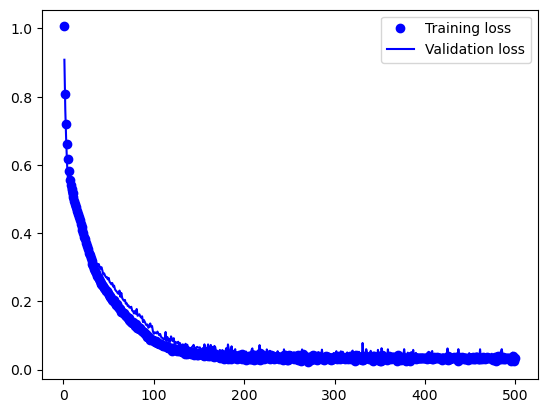

In [12]:
model.compile(optimizer='rmsprop', loss='mae', metrics=['mae'])
history = model.fit(x_train,
                    y_train,
                    epochs=500,
                    batch_size=100,
                    validation_data=(x_val, y_val))

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.legend()
plt.show()

In [13]:
print(x_test.shape)

(200,)


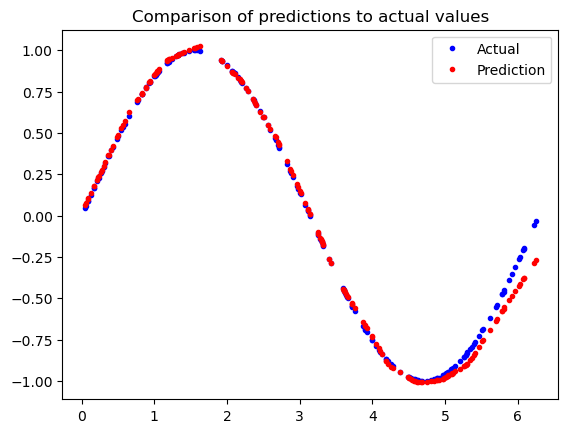

In [14]:
predictions = model.predict(x_test)

plt.clf()
plt.title("Comparison of predictions to actual values")
plt.plot(x_test, y_test, 'b.', label='Actual')
plt.plot(x_test, predictions, 'r.', label='Prediction')
plt.legend()
plt.show()

In [15]:
# test data to c file 
save_model(model, model_name)